In [1]:
# To run only once or else restart the kernel
# or change manually the current directory so that it is Networks_project/
import os
os.chdir("../")

In [ ]:
import plotly.express as px
import matplotlib.pyplot as plt

from src.geography_utils import import_location_data, plot_type_repartion_log

## Importation de la donnée

On regroupe par lieu et on compte le nombre d'utilisateurs uniques qui sont venus.

In [3]:
path_data_check_in='data/dataset_TSMC2014_TKY.txt'

df = import_location_data(path_data_check_in)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67805 entries, 0 to 67804
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   location_id         67805 non-null  str    
 1   latitude            67805 non-null  float64
 2   longitude           67805 non-null  float64
 3   location_type_ID    67805 non-null  str    
 4   location_type_name  67805 non-null  str    
 5   nb_checkins         67805 non-null  int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 3.1 MB


## Premier parcours de la donnée

On ne conserve que les types de lieux très visités pour la répartition par type :

In [5]:
df_loc_type = df.groupby("location_type_ID")["nb_checkins"].agg("sum")
threshold = df_loc_type.sum()/100
filtered_types = list(df_loc_type[df_loc_type >= threshold].index)
print(f"Number of location types with number of check-ins above the threshold ({threshold}): {len(filtered_types)}.")

Number of location types with number of check-ins above the threshold (2199.34): 23.


In [6]:
fig = plot_type_repartion_log(df, filtered_types)

fig.show()

Les services de restauration sont très présents à faible nombre de check-ins, et les gares à fort nombre de check-ins.

In [7]:
fig = px.scatter_map(
    df[df["nb_checkins"] >= 100],
    lat="latitude",
    lon="longitude",
    title="Locations in Tokyo with more than 100 checkins",
    color="location_type_name",
    size="nb_checkins",
    size_max=25,
    zoom=10,
    map_style="carto-positron"
)
fig.show()

Il est clair: ce sont les gares qui sont les plus visitées. Etant donné que celles-ci sont très fréquentées au quotidien et, qu'au Japon, elles proposent souvent des tampons à collectionner dans des carnets, il est courant de partager ses collectes de tampons sur les réseaux. Cela pourrait donc expliquer le grand nombre de check-ins pour ce type de lieu. 

## Séparation centre/banlieue

In [8]:
import geopandas as gpd
import numpy as np

In [59]:
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
).to_crs(3857)

gdf["log_checkins"] = np.log1p(gdf["nb_checkins"])

On répartit les points selon s'ils sont dans ou en dehors du centre dense (zones crées à partir de `src/tokyo_map.py`).

In [60]:
tokyo_wards = gpd.read_file("data/tokyo_wards.geo.json").to_crs(3857)
central_wards = ["Shibuya", "Shinjuku", "Chiyoda", "Chūō", "Minato", "Taitō",
                 "Bunkyō", "Sumida", "Nakano", "Toshima", "Meguro", "Shinagawa"]

tokyo_center = tokyo_wards[tokyo_wards["NAME_2"].isin(central_wards)]

In [67]:
gdf_joined = gpd.sjoin(
    gdf,
    tokyo_wards[["NAME_2", "geometry"]],
    how="left",
    predicate="within"
)
gdf_joined["zone"] = gdf_joined["NAME_2"].isin(central_wards).map({True: "centre", False: "peripherie"})

checkins = gdf_joined.groupby("NAME_2")["nb_checkins"].sum()
# Densities
tokyo_wards = tokyo_wards.to_crs(3857)
tokyo_wards["area_km2"] = tokyo_wards.geometry.area / 1e6

wards_stats = tokyo_wards.merge(checkins, on="NAME_2", how="left")
wards_stats["density"] = wards_stats["nb_checkins"] / wards_stats["area_km2"]
wards_stats["density_log"] = np.log1p(wards_stats["density"])

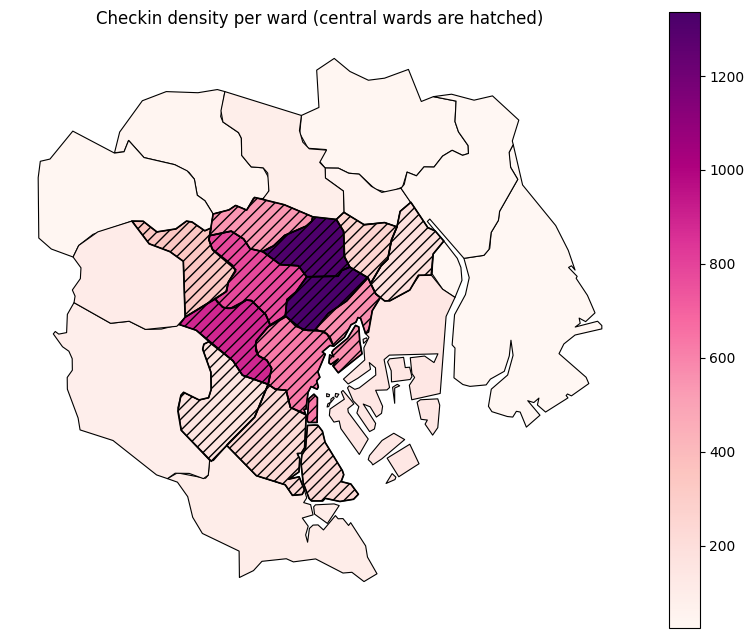

In [84]:
fig, ax = plt.subplots(figsize=(10, 8))

wards_stats.plot(
    column="density",
    cmap="RdPu",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

tokyo_center.plot(
    ax=ax,
    facecolor="none",      # IMPORTANT → pas de couleur
    edgecolor="black",     # contour
    linewidth=1.2,
    hatch="///"            # style de hachures (///, xxx, ...)
)

plt.title("Checkin density per ward (central wards are hatched)")
plt.axis("off")
plt.show()

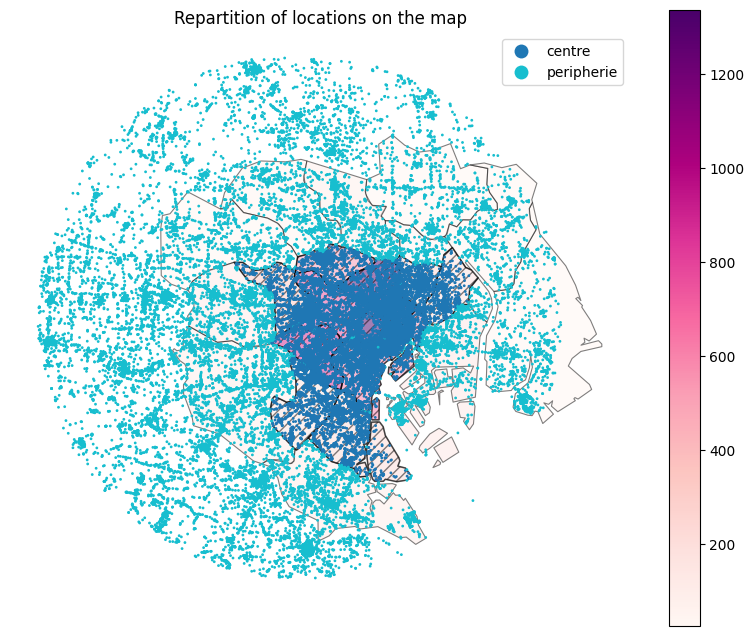

In [85]:
fig, ax = plt.subplots(figsize=(10, 8))

wards_stats.plot(
    column="density",
    cmap="RdPu",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax,
    alpha=0.5
)

tokyo_center.plot(
    ax=ax,
    facecolor="none",      # IMPORTANT → pas de couleur
    edgecolor="black",     # contour
    linewidth=1.2,
    hatch="///",
    alpha=0.5
)

gdf_joined.plot(
    ax=ax,
    column="zone",
    markersize=1,
    legend=True,
    alpha=1
)

plt.title("Repartition of locations on the map")
plt.axis("off")
plt.show()

On fait le choix de garder ces arrondissements centraux car ils présentent une forte concentration des lieux sur quasiment tout leur territoire, bien que certains aient une densité un peu moindre et similaire à des voisins non sélectionnés.

In [72]:
central_tokyo = gdf_joined[gdf_joined["zone"] == "centre"].reset_index(drop=True)
peripheral_tokyo = gdf_joined[gdf_joined["zone"] == "peripherie"].reset_index(drop=True)

## Corrélation géographique

On remarque également sur la carte précédente qu'il y a une forte concentration de lieux attractifs dans certains quartiers (Shibuya, Shinjuku, ...) : il est donc pertinant d'étudier la corrélation géographique.

In [81]:
from libpysal.weights import KNN
from esda.moran import Moran
from esda.moran import Moran_Local

### Dans le centre

In [ ]:
w = KNN.from_dataframe(central_tokyo, k=50)
w.transform = 'R'  # row-standardization

In [ ]:
y = central_tokyo["log_checkins"].values

mi = Moran(y, w)

print(mi.I, mi.p_sim)

0.09530859743784309 0.001


Il y a une forte autocorrélation entre le log(1 + nb_checkins) et la localisation géographique (plus proche voisins).

In [ ]:
lisa = Moran_Local(y, w)

central_tokyo["lisa_I"] = lisa.Is
central_tokyo["lisa_p"] = lisa.p_sim
central_tokyo["lisa_cluster"] = lisa.q
central_tokyo["lisa_cluster"] = central_tokyo["lisa_cluster"].map({1: "HH", 2: "LH", 3: "LL", 4: "HL"})

In [76]:
fig = px.scatter_map(
    central_tokyo[central_tokyo["lisa_p"] < 0.05],
    lat="latitude",
    lon="longitude",
    title="Lisa clusters in central Tokyo",
    color="lisa_cluster",
    zoom=10,
    map_style="carto-positron"
)
fig.show()

Les clusters HH sont ceux qui nous intéressent le plus.

Alors même que les arrondissements centraux sont denses, des clusters nets apparaissent dans les quartiers les plus tendance (Shibuya, Shinjuku, ...).

### Périphérie

In [ ]:
w = KNN.from_dataframe(peripheral_tokyo, k=50)
w.transform = 'R'  # row-standardization

In [ ]:
y = peripheral_tokyo["log_checkins"].values

mi = Moran(y, w)

print(mi.I, mi.p_sim)

0.058991793207183854 0.001


L'autocorrélation spaciale est presque deux fois plus faible en périphérie. Néanmoins il y en a bien une.

In [79]:
lisa = Moran_Local(y, w)

peripheral_tokyo["lisa_I"] = lisa.Is
peripheral_tokyo["lisa_p"] = lisa.p_sim
peripheral_tokyo["lisa_cluster"] = lisa.q
peripheral_tokyo["lisa_cluster"] = peripheral_tokyo["lisa_cluster"].map({1: "HH", 2: "LH", 3: "LL", 4: "HL"})

In [80]:
fig = px.scatter_map(
    peripheral_tokyo[peripheral_tokyo["lisa_p"] < 0.05],
    lat="latitude",
    lon="longitude",
    title="Lisa clusters in peripheral Tokyo",
    color="lisa_cluster",
    zoom=10,
    map_style="carto-positron"
)
fig.show()

Le seul endroit avec une forte concentration de HH est au niveau de la baie de Tokyo, qui est presque au centre (Appartient à un arrondissement très hétérogène en densité), à Kawasaki, et à Chofu. Alors que la zone est bien plus élargie, de tels grand clusters ont du mal à se profiler : il y a bien une plus faible corrélation géographique dans la périphérie.